In [1]:
# !pip install pydantic==1.10.14
!pip install ydata-profiling

In [2]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
print(pd.__version__)

# import pandas_profiling

2.2.3


In [4]:
import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

/kaggle/input/house-prices-advanced-regression-techniques/sample_submission.csv
/kaggle/input/house-prices-advanced-regression-techniques/data_description.txt
/kaggle/input/house-prices-advanced-regression-techniques/train.csv
/kaggle/input/house-prices-advanced-regression-techniques/test.csv


# Data Exploration and Description 数据描述探查

Here’s a concise **one-line summary** for each feature, first in **English**, then in **Chinese**:  

---

### **Structural & Property Features**  
1. **MSSubClass**: Identifies the type of dwelling. / 住宅类型编码。  
2. **MSZoning**: General zoning classification. / 地块分区类型。  
3. **LotFrontage**: Linear street footage connected to the property. / 临街面长度（英尺）。  
4. **LotArea**: Lot size in square feet. / 地块面积（平方英尺）。  
5. **Street**: Road access type (paved/gravel). / 道路类型（铺装/砂石）。  
6. **Alley**: Alley access type (paved/gravel/none). / 小巷类型（铺装/砂石/无）。  
7. **LotShape**: Property shape regularity. / 地块形状规则性。  
8. **LandContour**: Flatness of the land. / 地块平坦度。  
9. **Utilities**: Available utilities (electricity, gas, etc.). / 可用公用设施。  
10. **LotConfig**: Lot layout (corner, cul-de-sac, etc.). / 地块配置（角落、死胡同等）。  
11. **LandSlope**: Property slope severity. / 地块坡度。  

### **Neighborhood & Location**  
12. **Neighborhood**: Physical location within Ames. / 房屋所在社区。  
13. **Condition1/2**: Proximity to roads/railroads/parks. / 邻近主路/铁路/公园等。  

### **Building Characteristics**  
14. **BldgType**: Dwelling type (single-family, duplex, etc.). / 建筑类型（独栋、双拼等）。  
15. **HouseStyle**: Architectural style (1-story, split-level, etc.). / 房屋风格（平层、错层等）。  
16. **OverallQual**: Overall material/finish quality (1-10). / 整体材料/装修质量（1-10分）。  
17. **OverallCond**: Overall condition rating (1-10). / 整体维护状况（1-10分）。  
18. **YearBuilt**: Original construction year. / 建造年份。  
19. **YearRemodAdd**: Remodeling year. / 翻修年份。  

### **Roof & Exterior**  
20. **RoofStyle**: Roof design (gable, flat, etc.). / 屋顶样式（山形、平等）。  
21. **RoofMatl**: Roof material (shingle, tile, etc.). / 屋顶材料（瓦、沥青等）。  
22. **Exterior1st/2nd**: Primary/secondary exterior covering. / 外墙主要/次要材料。  
23. **MasVnrType**: Masonry veneer type (brick, stone). / 砖石饰面类型。  
24. **MasVnrArea**: Masonry veneer area (sq ft). / 砖石饰面面积（平方英尺）。  
25. **ExterQual**: Exterior material quality. / 外部材料质量评级。  
26. **ExterCond**: Exterior condition. / 外部维护状况评级。  

### **Basement & Foundation**  
27. **Foundation**: Foundation type (concrete, slab, etc.). / 地基类型（混凝土、板等）。  
28. **BsmtQual**: Basement height quality. / 地下室高度评级。  
29. **BsmtCond**: Basement general condition. / 地下室状况评级。  
30. **BsmtExposure**: Walkout/garden wall exposure. / 地下室采光/通风评级。  
31. **BsmtFinType1/2**: Finished basement area rating. / 地下室装修类型评级。  
32. **BsmtFinSF1/2**: Finished basement area (sq ft). / 地下室装修面积（平方英尺）。  
33. **TotalBsmtSF**: Total basement area (sq ft). / 地下室总面积（平方英尺）。  

### **Interior & Living Space**  
34. **Heating**: Heating system type. / 供暖系统类型。  
35. **HeatingQC**: Heating system quality. / 供暖系统质量评级。  
36. **CentralAir**: Central air conditioning (Y/N). / 中央空调（有/无）。  
37. **Electrical**: Electrical system type. / 电路系统类型。  
38. **1stFlrSF/2ndFlrSF**: First/second floor area (sq ft). / 一楼/二楼面积（平方英尺）。  
39. **GrLivArea**: Above-grade living area (sq ft). / 地上居住面积（平方英尺）。  
40. **Bedroom/Kitchen**: Number of bedrooms/kitchens. / 卧室/厨房数量。  
41. **KitchenQual**: Kitchen quality rating. / 厨房质量评级。  
42. **TotRmsAbvGrd**: Total rooms above grade. / 地上总房间数。  
43. **Functional**: Home functionality rating. / 房屋功能性评级。  

### **Garage & Outdoor**  
44. **GarageType**: Garage location (attached, detached). / 车库位置（独立/附属等）。  
45. **GarageYrBlt**: Garage construction year. / 车库建造年份。  
46. **GarageFinish**: Interior garage finish. / 车库内部装修程度。  
47. **GarageCars/Area**: Garage size (cars/sq ft). / 车库容量（车位/平方英尺）。  
48. **PavedDrive**: Driveway pavement (full/partial/none). / 车道铺装情况。  
49. **WoodDeckSF/OpenPorchSF**: Deck/porch area (sq ft). / 木制平台/开放式门廊面积。  
50. **PoolArea/PoolQC**: Pool size and quality. / 泳池面积/质量评级。  
51. **Fence**: Fence quality. / 围栏质量评级。  

### **Sale & Transaction**  
52. **MoSold/YrSold**: Sale month/year. / 出售月份/年份。  
53. **SaleType**: Transaction type (new, warranty deed, etc.). / 销售类型（新房、产权转让等）。  
54. **SaleCondition**: Sale condition (normal, foreclosure, etc.). / 销售条件（正常、拍卖等）。  


In [3]:
house_df = pd.read_csv('/kaggle/input/house-prices-advanced-regression-techniques/train.csv')
house_df.head()

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000


In [4]:
display(house_df.info())

house_df.shape

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1460 entries, 0 to 1459
Data columns (total 81 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             1460 non-null   int64  
 1   MSSubClass     1460 non-null   int64  
 2   MSZoning       1460 non-null   object 
 3   LotFrontage    1201 non-null   float64
 4   LotArea        1460 non-null   int64  
 5   Street         1460 non-null   object 
 6   Alley          91 non-null     object 
 7   LotShape       1460 non-null   object 
 8   LandContour    1460 non-null   object 
 9   Utilities      1460 non-null   object 
 10  LotConfig      1460 non-null   object 
 11  LandSlope      1460 non-null   object 
 12  Neighborhood   1460 non-null   object 
 13  Condition1     1460 non-null   object 
 14  Condition2     1460 non-null   object 
 15  BldgType       1460 non-null   object 
 16  HouseStyle     1460 non-null   object 
 17  OverallQual    1460 non-null   int64  
 18  OverallC

None

(1460, 81)

In [16]:
type_dict= house_df.dtypes.to_dict()
type_dict

{'Id': dtype('int64'),
 'MSSubClass': dtype('int64'),
 'MSZoning': dtype('O'),
 'LotFrontage': dtype('float64'),
 'LotArea': dtype('int64'),
 'Street': dtype('O'),
 'Alley': dtype('O'),
 'LotShape': dtype('O'),
 'LandContour': dtype('O'),
 'Utilities': dtype('O'),
 'LotConfig': dtype('O'),
 'LandSlope': dtype('O'),
 'Neighborhood': dtype('O'),
 'Condition1': dtype('O'),
 'Condition2': dtype('O'),
 'BldgType': dtype('O'),
 'HouseStyle': dtype('O'),
 'OverallQual': dtype('int64'),
 'OverallCond': dtype('int64'),
 'YearBuilt': dtype('int64'),
 'YearRemodAdd': dtype('int64'),
 'RoofStyle': dtype('O'),
 'RoofMatl': dtype('O'),
 'Exterior1st': dtype('O'),
 'Exterior2nd': dtype('O'),
 'MasVnrType': dtype('O'),
 'MasVnrArea': dtype('float64'),
 'ExterQual': dtype('O'),
 'ExterCond': dtype('O'),
 'Foundation': dtype('O'),
 'BsmtQual': dtype('O'),
 'BsmtCond': dtype('O'),
 'BsmtExposure': dtype('O'),
 'BsmtFinType1': dtype('O'),
 'BsmtFinSF1': dtype('int64'),
 'BsmtFinType2': dtype('O'),
 'BsmtF

In [12]:
# sns.displot(data=house_df.isnull().melt(value_name='missing'),
#     y='variable',
#     hue='missing',
#     multiple='fill',
#     height=8,
# #     width=10,
#     aspect=1.6
# )

# # specifying a threshold value, 看每列缺失值是否超过40%
# plt.axvline(0.1, color='r')
# plt.title('Null Values in Train Data', fontsize=13)
# plt.show()

In [6]:
# missing value 缺失值检测
print(' ==== missing check ==== ')
miss_df = house_df.isnull().sum()
# missing_cols = miss_df[house_df.isnull().sum() > 0]

missing_ratio = miss_df / len(house_df) * 100
print(missing_ratio)

print("有缺失值的列，缺失值比例 >0（%）======= ")
print(missing_ratio[missing_ratio > 0])
# missing_cols

 ==== missing check ==== 
Id                0.000000
MSSubClass        0.000000
MSZoning          0.000000
LotFrontage      17.739726
LotArea           0.000000
                   ...    
MoSold            0.000000
YrSold            0.000000
SaleType          0.000000
SaleCondition     0.000000
SalePrice         0.000000
Length: 81, dtype: float64
有缺失值的列，缺失值比例 >0（%）======= 
LotFrontage     17.739726
Alley           93.767123
MasVnrType      59.726027
MasVnrArea       0.547945
BsmtQual         2.534247
BsmtCond         2.534247
BsmtExposure     2.602740
BsmtFinType1     2.534247
BsmtFinType2     2.602740
Electrical       0.068493
FireplaceQu     47.260274
GarageType       5.547945
GarageYrBlt      5.547945
GarageFinish     5.547945
GarageQual       5.547945
GarageCond       5.547945
PoolQC          99.520548
Fence           80.753425
MiscFeature     96.301370
dtype: float64


In [9]:
# drop column, missing > 10%
cols_to_keep = miss_df[missing_ratio <= 10].index
print(cols_to_keep)

clean_house = house_df[cols_to_keep]
clean_house.shape

Index(['Id', 'MSSubClass', 'MSZoning', 'LotArea', 'Street', 'LotShape',
       'LandContour', 'Utilities', 'LotConfig', 'LandSlope', 'Neighborhood',
       'Condition1', 'Condition2', 'BldgType', 'HouseStyle', 'OverallQual',
       'OverallCond', 'YearBuilt', 'YearRemodAdd', 'RoofStyle', 'RoofMatl',
       'Exterior1st', 'Exterior2nd', 'MasVnrArea', 'ExterQual', 'ExterCond',
       'Foundation', 'BsmtQual', 'BsmtCond', 'BsmtExposure', 'BsmtFinType1',
       'BsmtFinSF1', 'BsmtFinType2', 'BsmtFinSF2', 'BsmtUnfSF', 'TotalBsmtSF',
       'Heating', 'HeatingQC', 'CentralAir', 'Electrical', '1stFlrSF',
       '2ndFlrSF', 'LowQualFinSF', 'GrLivArea', 'BsmtFullBath', 'BsmtHalfBath',
       'FullBath', 'HalfBath', 'BedroomAbvGr', 'KitchenAbvGr', 'KitchenQual',
       'TotRmsAbvGrd', 'Functional', 'Fireplaces', 'GarageType', 'GarageYrBlt',
       'GarageFinish', 'GarageCars', 'GarageArea', 'GarageQual', 'GarageCond',
       'PavedDrive', 'WoodDeckSF', 'OpenPorchSF', 'EnclosedPorch', '3SsnPorch'

(1460, 74)

In [18]:
# 对于 缺失率[0, 10]，填充缺失值
fill_col = missing_ratio[(missing_ratio <= 10) & (missing_ratio>0)]
print(fill_col.index.to_list())

for col in fill_col.index.to_list():
    if type_dict[col] == type_dict['Street']:
          # object type fill none
        clean_house[col] = clean_house[col].fillna("None")
    else:
        # numeric fill 0
        clean_house[col] = clean_house[col].fillna(0)

clean_house.head()

['MasVnrArea', 'BsmtQual', 'BsmtCond', 'BsmtExposure', 'BsmtFinType1', 'BsmtFinType2', 'Electrical', 'GarageType', 'GarageYrBlt', 'GarageFinish', 'GarageQual', 'GarageCond']


,Id,MSSubClass,MSZoning,LotArea,Street,LotShape,LandContour,Utilities,LotConfig,LandSlope,...,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,8450,Pave,Reg,Lvl,AllPub,Inside,Gtl,...,0,0,0,0,0,2,2008,WD,Normal,208500
1,2,20,RL,9600,Pave,Reg,Lvl,AllPub,FR2,Gtl,...,0,0,0,0,0,5,2007,WD,Normal,181500
2,3,60,RL,11250,Pave,IR1,Lvl,AllPub,Inside,Gtl,...,0,0,0,0,0,9,2008,WD,Normal,223500
3,4,70,RL,9550,Pave,IR1,Lvl,AllPub,Corner,Gtl,...,272,0,0,0,0,2,2006,WD,Abnorml,140000
4,5,60,RL,14260,Pave,IR1,Lvl,AllPub,FR2,Gtl,...,0,0,0,0,0,12,2008,WD,Normal,250000


In [19]:
print('==== duplicated check ==== ')
display(clean_house.duplicated().sum())

# house_df.drop_duplicates(inplace=True)
# display(house_df.duplicated().sum())


# drop ID feature
clean_house.drop("Id", axis = 1, inplace = True)

==== duplicated check ==== 


0

In [20]:
clean_house.shape

(1460, 73)

In [21]:
dtypes = clean_house.dtypes.to_frame().reset_index()
dtypes.columns = ['col', 'dtype']
print('Df dtypes:')
dtypes.groupby('dtype').size()

Df dtypes:


dtype
int64      34
float64     2
object     37
dtype: int64

## check correlation 筛选重要feature

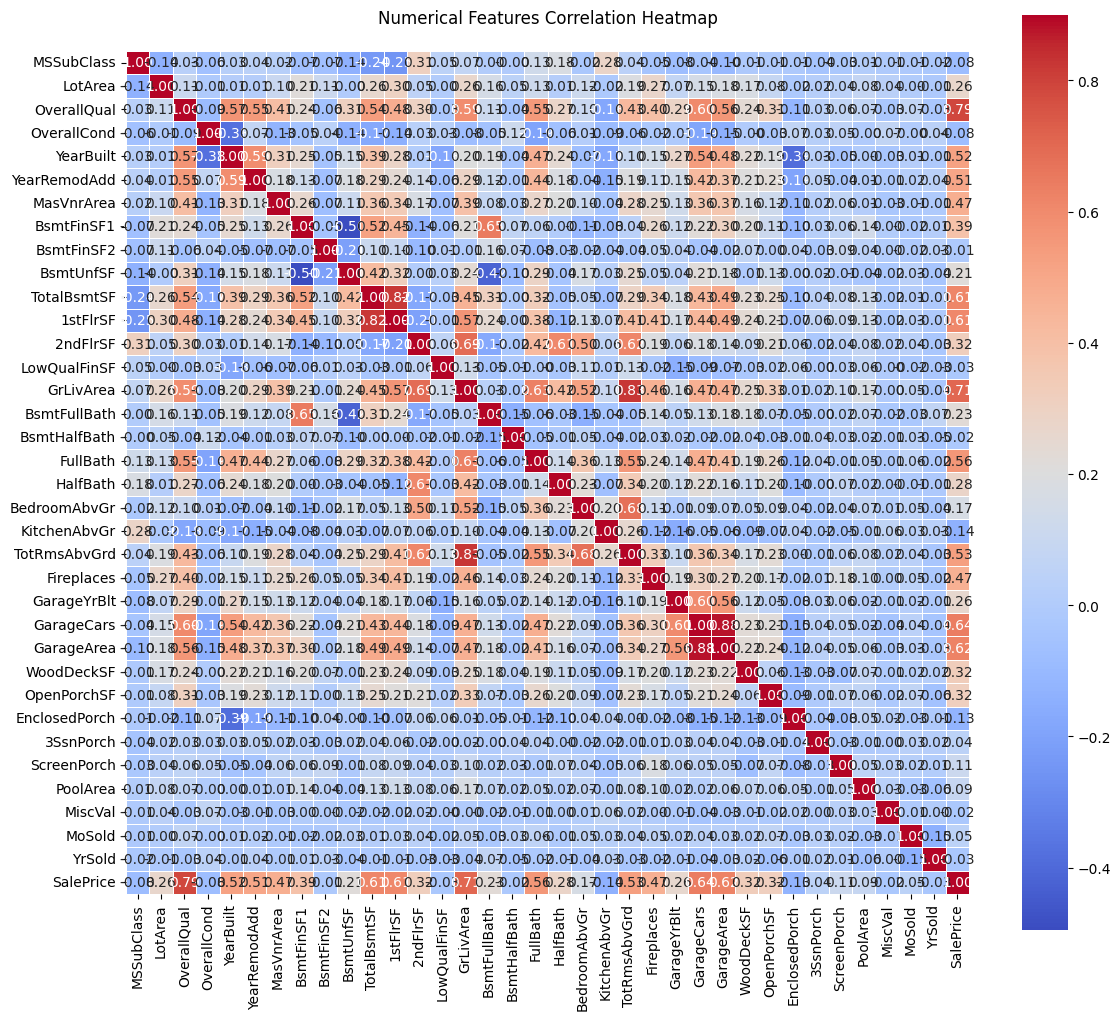

In [242]:
# heatmap
# SalePrice
# sns.heatmap(clean_house.select_dtypes(exclude='object').corr(), vmax=0.9, square=True)
corr_matrix = clean_house.select_dtypes(exclude='object').corr()
plt.figure(figsize=(12, 12))

heatmap = sns.heatmap(
    corr_matrix,
    vmax=0.9,        # 颜色最大值（相关性范围）
    square=True,      # 使单元格为正方形
    annot=True,       # 显示数值
    fmt=".2f",       # 数值格式（保留2位小数）
    cmap='coolwarm', # 颜色映射（红-蓝渐变）
    linewidths=0.5,  # 单元格边框线宽
    cbar_kws={"shrink": 0.8}  # 调整颜色条大小
)
plt.title("Numerical Features Correlation Heatmap", pad=20)
plt.tight_layout()
plt.show()

In [184]:
def get_corr_list(df, threshold = 0.6):
    corr = df.corr().unstack().to_frame().reset_index()
    corr.columns = ['var1', 'var2', 'corr']

    corr = corr[corr['var1'] != corr['var2']]
    
    corr['abs_corr'] = corr['corr'].abs()
    corr = corr.sort_values(by='abs_corr', ascending=False)
    corr = corr[corr['abs_corr'] > threshold]

    corr = corr.iloc[::2]
    return corr

corr_list = get_corr_list(clean_house.select_dtypes(exclude='object'))
corr_list

,var1,var2,corr,abs_corr
889,GarageCars,GarageArea,0.882475,0.882475
167,YearBuilt,GarageYrBlt,0.825667,0.825667
525,GrLivArea,TotRmsAbvGrd,0.825489,0.825489
371,TotalBsmtSF,1stFlrSF,0.819530,0.819530
1262,SalePrice,OverallQual,0.790982,0.790982
539,GrLivArea,SalePrice,0.708624,0.708624
516,GrLivArea,2ndFlrSF,0.687501,0.687501
775,TotRmsAbvGrd,BedroomAbvGr,0.676620,0.676620
267,BsmtFinSF1,BsmtFullBath,0.649212,0.649212
833,GarageYrBlt,YearRemodAdd,0.642277,0.642277


In [186]:
same_col = corr_list[corr_list['corr']>0.8]['var1']

compact = clean_house.drop(same_col, axis=1)
# selected_feature
# cat_cols = clean_house.select_dtypes(include='object').columns.to_list()
# cat_cols

compact.shape, clean_house.shape

((1460, 69), (1460, 73))

In [187]:
compact.columns

Index(['MSSubClass', 'MSZoning', 'LotArea', 'Street', 'LotShape',
       'LandContour', 'Utilities', 'LotConfig', 'LandSlope', 'Neighborhood',
       'Condition1', 'Condition2', 'BldgType', 'HouseStyle', 'OverallQual',
       'OverallCond', 'YearRemodAdd', 'RoofStyle', 'RoofMatl', 'Exterior1st',
       'Exterior2nd', 'MasVnrArea', 'ExterQual', 'ExterCond', 'Foundation',
       'BsmtQual', 'BsmtCond', 'BsmtExposure', 'BsmtFinType1', 'BsmtFinSF1',
       'BsmtFinType2', 'BsmtFinSF2', 'BsmtUnfSF', 'Heating', 'HeatingQC',
       'CentralAir', 'Electrical', '1stFlrSF', '2ndFlrSF', 'LowQualFinSF',
       'BsmtFullBath', 'BsmtHalfBath', 'FullBath', 'HalfBath', 'BedroomAbvGr',
       'KitchenAbvGr', 'KitchenQual', 'TotRmsAbvGrd', 'Functional',
       'Fireplaces', 'GarageType', 'GarageYrBlt', 'GarageFinish', 'GarageArea',
       'GarageQual', 'GarageCond', 'PavedDrive', 'WoodDeckSF', 'OpenPorchSF',
       'EnclosedPorch', '3SsnPorch', 'ScreenPorch', 'PoolArea', 'MiscVal',
       'MoSold', 'YrS

In [188]:
# non numeric columns
cat_cols = clean_house.select_dtypes(include='object').columns.to_list()
print(cat_cols)

['MSZoning', 'Street', 'LotShape', 'LandContour', 'Utilities', 'LotConfig', 'LandSlope', 'Neighborhood', 'Condition1', 'Condition2', 'BldgType', 'HouseStyle', 'RoofStyle', 'RoofMatl', 'Exterior1st', 'Exterior2nd', 'ExterQual', 'ExterCond', 'Foundation', 'BsmtQual', 'BsmtCond', 'BsmtExposure', 'BsmtFinType1', 'BsmtFinType2', 'Heating', 'HeatingQC', 'CentralAir', 'Electrical', 'KitchenQual', 'Functional', 'GarageType', 'GarageFinish', 'GarageQual', 'GarageCond', 'PavedDrive', 'SaleType', 'SaleCondition']


In [102]:
# https://docs.profiling.ydata.ai/latest/
from ydata_profiling import ProfileReport
profile = ProfileReport(clean_house[cat_cols], title="Profiling Report")
# house_df.profile_report()

In [106]:
profile.to_notebook_iframe()

In [ ]:
# numeric_profile = ProfileReport(new_df, title="numeric Profiling Report")
# numeric_profile.to_notebook_iframe()

<Axes: xlabel='SalePrice', ylabel='Density'>

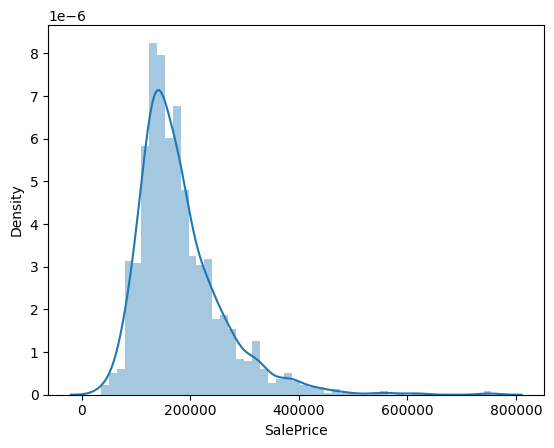

In [191]:
sns.distplot(clean_house['SalePrice'])

In [244]:
from scipy.stats import norm, skew

numeric_feats = clean_house.dtypes[clean_house.dtypes != "object"].index
skewed_feats = clean_house[numeric_feats].apply(lambda x: skew(x.dropna())).sort_values(ascending=False)
print("\nSkew in numerical features: \n")
skewness = pd.DataFrame({'Skew' :skewed_feats})
skewness.head(10)


Skew in numerical features: 



,Skew
MiscVal,24.451640
PoolArea,14.813135
LotArea,12.195142
3SsnPorch,10.293752
LowQualFinSF,9.002080
KitchenAbvGr,4.483784
BsmtFinSF2,4.250888
ScreenPorch,4.117977
BsmtHalfBath,4.099186
EnclosedPorch,3.086696


# Feature processing

In [22]:
from sklearn.preprocessing import LabelEncoder
cols = ('BsmtQual', 'BsmtCond', 'GarageQual', 'GarageCond', 
        'ExterQual', 'ExterCond','HeatingQC', 'KitchenQual', 'BsmtFinType1', 
        'BsmtFinType2', 'Functional', 'BsmtExposure', 'GarageFinish', 'LandSlope',
        'LotShape', 'PavedDrive', 'Street', 'CentralAir', 'MSSubClass', 'OverallCond', 
        'YrSold', 'MoSold')

# process columns, apply LabelEncoder to categorical features
house2 = clean_house.copy()

for c in cols:
    lbl = LabelEncoder() 
    lbl.fit(list(clean_house[c].values)) 
    house2[c] = lbl.transform(list(clean_house[c].values))

# encode shape        
print('Shape all_data: {}'.format(house2.shape))

Shape all_data: (1460, 73)


In [23]:
house2 = pd.get_dummies(house2)
print(house2.shape)

y = house2['SalePrice']
X = house2.drop(columns=['SalePrice'])

y.shape, X.shape

(1460, 210)


((1460,), (1460, 209))

In [24]:
X.columns[X.isna().sum() > 0] 

Index([], dtype='object')

In [230]:
# X['MasVnrArea'] = X['MasVnrArea'].fillna(0)
# X['GarageYrBlt'] = X['GarageYrBlt'].fillna(0)

In [26]:
from sklearn.model_selection import KFold, cross_val_score, train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 划分train, test dataset
X_train.shape, X_test.shape

((1168, 209), (292, 209))

In [52]:
display(X_train.head(5))

display(y_train.head(5))

,MSSubClass,LotArea,Street,LotShape,LandSlope,OverallQual,OverallCond,YearBuilt,YearRemodAdd,MasVnrArea,...,SaleType_ConLw,SaleType_New,SaleType_Oth,SaleType_WD,SaleCondition_Abnorml,SaleCondition_AdjLand,SaleCondition_Alloca,SaleCondition_Family,SaleCondition_Normal,SaleCondition_Partial
254,0,8400,1,3,0,5,5,1957,1957,0.0,...,False,False,False,True,False,False,False,False,True,False
1066,5,7837,1,0,0,6,6,1993,1994,0.0,...,False,False,False,True,False,False,False,False,True,False
638,1,8777,1,3,0,5,6,1910,1950,0.0,...,False,False,False,True,False,False,False,False,True,False
799,4,7200,1,3,0,5,6,1937,1950,252.0,...,False,False,False,True,False,False,False,False,True,False
380,4,5000,1,3,0,5,5,1924,1950,0.0,...,False,False,False,True,False,False,False,False,True,False


254     145000
1066    178000
638      85000
799     175000
380     127000
Name: SalePrice, dtype: int64

# Modelling

In [53]:
from sklearn.linear_model import ElasticNet, Lasso,  BayesianRidge, LassoLarsIC
from sklearn.ensemble import RandomForestRegressor,  GradientBoostingRegressor
from sklearn.linear_model import LinearRegression
from sklearn.kernel_ridge import KernelRidge
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import RobustScaler
from sklearn.base import BaseEstimator, TransformerMixin, RegressorMixin, clone
from catboost import CatBoostRegressor

from xgboost import XGBRegressor
from lightgbm import LGBMRegressor

from sklearn.metrics import mean_absolute_error, mean_squared_error, mean_absolute_percentage_error

from sklearn.neural_network import MLPRegressor

In [54]:
random_state = 42
regressors = {
    "RandomForestRegressor": (
        {
            'n_estimators': [50, 100, 200],
            'max_depth': [None, 10, 20],
            'min_samples_split': [2, 5, 10]
        },
        RandomForestRegressor(random_state=random_state)
    ),
    "CatBoostRegressor": (
        {
            'iterations': [100, 200, 300],
            'depth': [4, 6, 8],
            'learning_rate': [0.01, 0.1, 0.2]
        },
        CatBoostRegressor(random_seed=random_state, verbose=0)
    ),
    "XGBRegressor": (
        {
            'n_estimators': [50, 50, 1000],
            'max_depth': [3, 6, 3],
            'learning_rate': [0.01, 0.1, 0.01],
            'subsample': [0.6, 0.8, 1.0],
            'colsample_bytree': [0.6, 0.8, 1.0] #每棵决策树随机采样的特征比例
        },
        XGBRegressor(random_state=random_state, gamma=0.0468)
    ),
    "MLPRegressor":(
       {
        'hidden_layer_sizes': [(50,), (100,), (50, 30)],  # 网络结构
        'activation': ['relu', 'tanh'],                  # 激活函数
        'solver': ['adam', 'sgd'],                       # 优化器
        'alpha': [0.0001, 0.001, 0.01],                 # L2正则化强度
        'learning_rate_init': [0.001, 0.01]             # 初始学习率
        }, 
        MLPRegressor(max_iter=500, random_state=42)),
}


In [31]:
def rmsle_cv(model):
    rmse= np.sqrt(-cross_val_score(model, X_test.values, y_test, scoring="neg_mean_squared_error", cv = 5))
    return(rmse)

from sklearn.metrics import make_scorer
def rmse(y_true, y_pred):
    return -np.sqrt(mean_squared_error(y_true, y_pred))
    
# rmse_scorer = make_scorer(rmse, greater_is_better=False)
# scoring["rmse"] = rmse_scorer

In [56]:
import warnings
warnings.filterwarnings("ignore")

scoring = {
    "r2": "r2",
    "neg_mse": "neg_mean_squared_error",
    "neg_mae": "neg_mean_absolute_error",
}


from sklearn.model_selection import GridSearchCV
results = []

# 遍历所有模型
for model_name, (param_grid, model) in regressors.items():
    print(f"\n=== 正在调参 {model_name} ===")
    
    # 网格搜索最佳参数
    gs = GridSearchCV(model, param_grid, cv=5, scoring='r2', n_jobs=-1)
    gs.fit(X_train, y_train)
    
    # 输出结果
    print("最佳参数:", gs.best_params_)
    print("训练集 R2:", gs.best_score_)

    # evaluation
    y_pred = gs.predict(X_test)
    
    # 计算测试集 R² 和 MAE
    test_r2 = gs.score(X_test, y_test)  # R²
    test_mape = mean_absolute_percentage_error(y_test, y_pred)  # MAE
    print("测试集 R²:", test_r2)
    print("测试集 MAPE:", test_mape)
    
    # 保存结果用于可视化
    results.append({
        'Model': model_name,
        'Best Params': gs.best_params_,
        'Train R2': gs.best_score_,
        'Test R2': test_r2,
        'Test MAPE': test_mape
    })


=== 正在调参 RandomForestRegressor ===
最佳参数: {'max_depth': None, 'min_samples_split': 2, 'n_estimators': 100}
训练集 R2: 0.8423241738772415
测试集 R²: 0.8974701182408652
测试集 MAPE: 0.10617882797399375

=== 正在调参 CatBoostRegressor ===
最佳参数: {'depth': 6, 'iterations': 300, 'learning_rate': 0.1}
训练集 R2: 0.8819473227364121
测试集 R²: 0.907804367512902
测试集 MAPE: 0.0929523346762723

=== 正在调参 XGBRegressor ===
最佳参数: {'colsample_bytree': 0.8, 'learning_rate': 0.1, 'max_depth': 3, 'n_estimators': 1000, 'subsample': 0.8}
训练集 R2: 0.8806921952357974
测试集 R²: 0.9182287656701379
测试集 MAPE: 0.09321182131184075

=== 正在调参 MLPRegressor ===


/usr/local/lib/python3.11/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:686: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (500) reached and the optimization hasn't converged yet.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:686: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (500) reached and the optimization hasn't converged yet.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:686: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (500) reached and the optimization hasn't converged yet.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:686: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (500) reached and the optimization hasn't converged yet.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/neural_network/_multilayer_perceptro

最佳参数: {'activation': 'relu', 'alpha': 0.001, 'hidden_layer_sizes': (50, 30), 'learning_rate_init': 0.01, 'solver': 'adam'}
训练集 R2: 0.7016852374972302
测试集 R²: 0.7691218061413666
测试集 MAPE: 0.15434313991420173


# Visualization Model


=== 模型性能比较 ===


,Model,Train R2,Test R2,Test MAPE
0,RandomForestRegressor,0.842324,0.897470,0.106179
1,CatBoostRegressor,0.881947,0.907804,0.092952
2,XGBRegressor,0.880692,0.918229,0.093212
3,MLPRegressor,0.701685,0.769122,0.154343


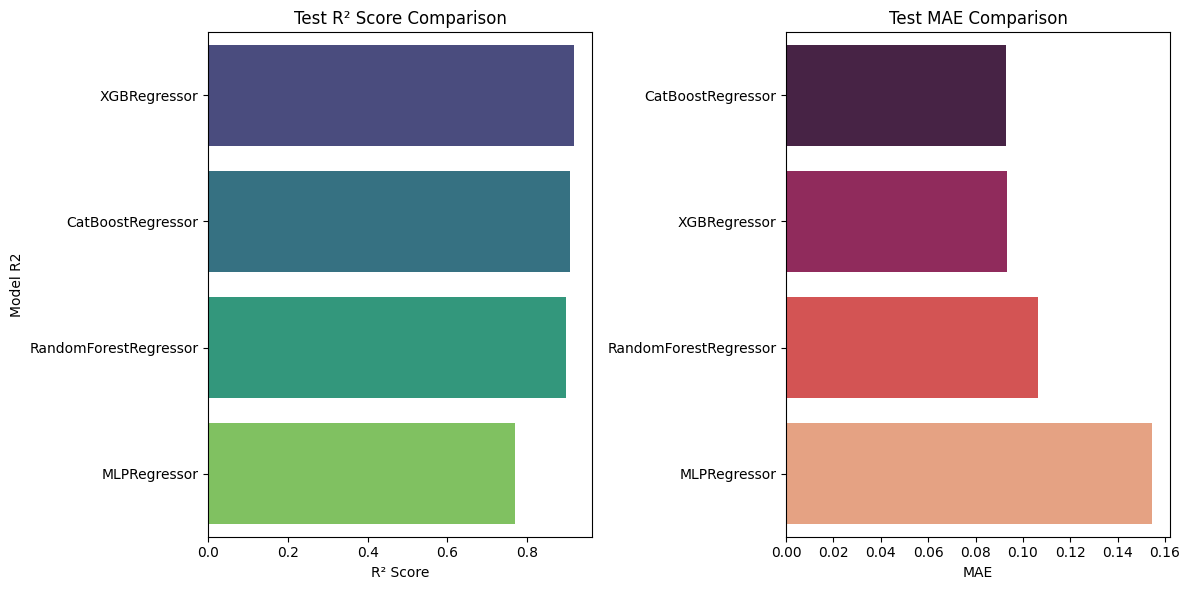

In [ ]:
# 创建结果DataFrame
results_df = pd.DataFrame(results)

# 1. 输出结果表格
print("\n=== 模型性能比较 ===")
display(results_df[['Model', 'Train R2', 'Test R2', 'Test MAPE']])


# 2. 可视化 - 模型性能比较
plt.figure(figsize=(12, 6))

# R²比较
plt.subplot(1, 2, 1)
sns.barplot(x='Test R2', y='Model', data=results_df.sort_values('Test R2', ascending=False), palette='viridis')
plt.title('Test R² Score Comparison')
plt.xlabel('R² Score')
plt.ylabel('Model R2')

# MAE比较
plt.subplot(1, 2, 2)
sns.barplot(x='Test MAPE', y='Model', data=results_df.sort_values('Test MAPE'), palette='rocket')
plt.title('Test MAE Comparison')
plt.xlabel('MAE')
plt.ylabel('')

plt.tight_layout()
plt.show()

# 3. 预测值与真实值对比图
plt.figure(figsize=(15, 4*len(regressors)))

for i, model_name in enumerate(results_df['Model']):
    plt.subplot(len(regressors), 1, i+1)
    gs = GridSearchCV(regressors[model_name][1], regressors[model_name][0], cv=5, scoring='r2')
    gs.fit(X_train, y_train)
    y_pred = gs.predict(X_test)
    
    sns.scatterplot(x=y_test, y=y_pred, alpha=0.6)
    plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')
    plt.title(f'{model_name} - True vs Predicted Values')
    plt.xlabel('True Values')
    plt.ylabel('Predicted Values')
    plt.grid(True)

plt.tight_layout()
plt.show()